## 🚀 How to Run & Hardware Requirements

### GPU Requirements
- **Recommended:** **A100** or **L4 GPU** (Requires Colab Pro/Pro+). The Qwen 7B vision and text models, especially during the QLoRA fine-tuning phase, require significant VRAM.
- **Free Tier (T4 GPU):** You might run into Out-Of-Memory (OOM) errors with the 7B model. If you are using a T4, it is highly recommended to change the `MODEL_ID` to `Qwen/Qwen2.5-VL-3B-Instruct` when loading models and fine-tuning.

### Instructions
1. **Runtime:** Go to `Runtime > Change runtime type` and select a suitable GPU.
2. **Execution:** Run the cells sequentially from top to bottom.
3. **Inputs:**
   - You will be prompted to upload an image file using an interactive widget in Step 1.
   - You need to provide valid API keys for **Pexels**, **OpenAI**, **Anthropic** (Claude), and **Weights & Biases** (W&B) in the designated cells to generate the dataset and log training metrics.
4. **Restarts:** Pay attention to any cells that explicitly ask you to restart the session after installing dependencies.

# Open-Source Image Analysis → Edit-JSON Pipeline

This notebook uses **open-source / open-weight Hugging Face models** for:

1. **Image analysis** with `Qwen/Qwen2.5-VL-7B-Instruct`
2. **JSON edit suggestion generation** with `Qwen/Qwen2.5-7B-Instruct`

It does **not** perform image editing.
Instead, it returns a JSON payload you can pass into your existing image editing API together with the uploaded image.

In [1]:
# ☀️ SKIP THIS CELL AFTER RESTARTING SESSION ☀️
# Install dependencies

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers accelerate bitsandbytes sentencepiece qwen-vl-utils
!pip install -q pillow matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.2 MB/s eta 0:00:00


## 🛠️ Environment Setup & Imports
This section loads the core libraries (`torch`, `transformers`, `PIL`, etc.) and configures the hardware device (CUDA if a GPU is available, otherwise CPU) for model inference.

In [1]:
import os
import json
import torch
import ipywidgets as widgets
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from transformers import (
    AutoProcessor,
    AutoTokenizer,
    AutoModelForCausalLM,
    Qwen2_5_VLForConditionalGeneration,
)

from qwen_vl_utils import process_vision_info


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("device =", device)
print("dtype  =", dtype)


device = cuda
dtype  = torch.float16


## Upload image

In [3]:
upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload image"
)
display(upload_widget)

UPLOADED_IMAGE_PATH = None


FileUpload(value={}, accept='image/*', description='Upload image')

In [7]:
# Run this AFTER you upload the image above

if not upload_widget.value:
    raise ValueError("Please upload an image first.")

uploaded_item = list(upload_widget.value.values())[0]
filename = uploaded_item["metadata"]["name"]
content = uploaded_item["content"]

os.makedirs("uploads", exist_ok=True)
UPLOADED_IMAGE_PATH = os.path.join("uploads", filename)

with open(UPLOADED_IMAGE_PATH, "wb") as f:
    f.write(content)

print("Saved to:", UPLOADED_IMAGE_PATH)


Saved to: uploads/test-image.webp


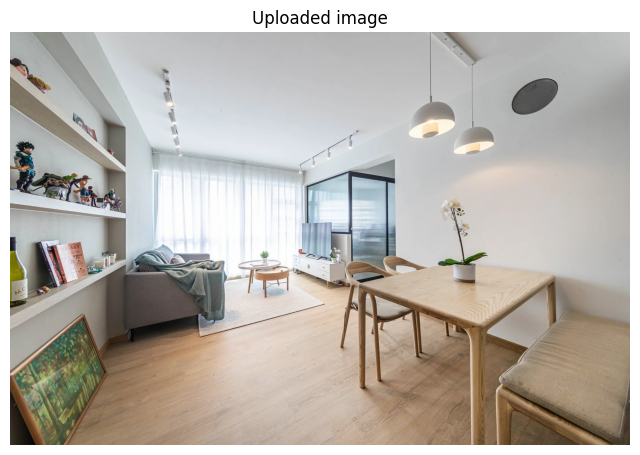

In [8]:
def show_image(path, title="Uploaded image", figsize=(8, 8)):
    img = Image.open(path).convert("RGB")
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

if UPLOADED_IMAGE_PATH:
    show_image(UPLOADED_IMAGE_PATH)


## Load open-source Hugging Face models

In [6]:
VISION_MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
TEXT_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

vision_processor = AutoProcessor.from_pretrained(
    VISION_MODEL_ID,
    trust_remote_code=True
)

vision_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    VISION_MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True
)

text_tokenizer = AutoTokenizer.from_pretrained(
    TEXT_MODEL_ID,
    trust_remote_code=True
)

text_model = AutoModelForCausalLM.from_pretrained(
    TEXT_MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True
)

print("Loaded vision model:", VISION_MODEL_ID)
print("Loaded text model:", TEXT_MODEL_ID)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded vision model: Qwen/Qwen2.5-VL-7B-Instruct
Loaded text model: Qwen/Qwen2.5-7B-Instruct


## Step 1 — Analyze the image and return household objects

In [9]:
def extract_json_block(text: str):
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        candidate = text[start:end+1]
        return json.loads(candidate)

    raise ValueError("No valid JSON found in model output")


def analyze_image_objects(image_path: str):
    image = Image.open(image_path).convert("RGB")

    instruction = """You are an interior image analysis assistant.

Task:
Identify visible household / room / furniture / decor / fixture objects from the image.

Return ONLY valid JSON in the following format:
{
  "objects": ["vase", "cabinet", "door"],
  "room_type": "living room",
  "scene_style": "modern",
  "object_notes": {
    "vase": "small tabletop vase",
    "cabinet": "wooden storage cabinet",
    "door": "single wooden door",
    "wall": "white coloured",
    "painting: "a painting that details..."
  }
}

Rules:
- Only include visible objects
- Keep object names short
- object_notes should be short visual descriptions
- No markdown
- No explanations outside JSON
"""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": instruction},
            ],
        }
    ]

    prompt_text = vision_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = vision_processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(vision_model.device)

    generated_ids = vision_model.generate(
        **inputs,
        max_new_tokens=300
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = vision_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return extract_json_block(output_text), output_text


## Step 2 — Convert object list + user prompt into edit JSON

In [10]:
def generate_edit_json(user_prompt: str, vision_output: dict):
    system_prompt = """You are an interior design transformation planner.

Input:
1. A user\'s desired style or transformation request
2. Detected objects from an image

Goal:
Return edit suggestions for an image editing model.

Return ONLY valid JSON in the following format:
{
  "global_style": "Japanese themed house",
  "edits": [
    {
      "object": "vase",
      "description": "a ceramic vase with pink sakura patterns"
    },
    {
      "object": "cabinet",
      "description": "a light oak cabinet with minimalist Japanese joinery"
    }
  ]
}

Rules:
- Only edit objects that exist in the detected object list
- Descriptions must be visual, concise, and useful for image editing
- Prefer 3 to 8 edits
- Do not invent missing objects
- No markdown
- No extra explanations
"""

    user_content = f"""User request:
{user_prompt}

Detected objects:
{json.dumps(vision_output, indent=2)}
"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content}
    ]

    text = text_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = text_tokenizer([text], return_tensors="pt").to(text_model.device)

    generated_ids = text_model.generate(
        **model_inputs,
        max_new_tokens=500,
        temperature=0.2,
        do_sample=True
    )

    new_tokens = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    output_text = text_tokenizer.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0]

    return extract_json_block(output_text), output_text


## Run the pipeline

In [11]:
# Change this prompt as needed
user_prompt = "I want a Japanese themed house"

if not UPLOADED_IMAGE_PATH:
    raise ValueError("Please upload and save an image first.")

vision_json, vision_raw = analyze_image_objects(UPLOADED_IMAGE_PATH)

print("VISION JSON")
print(json.dumps(vision_json, indent=2))

edit_json, edit_raw = generate_edit_json(user_prompt, vision_json)

print("\nEDIT JSON")
print(json.dumps(edit_json, indent=2))

VISION JSON
{
  "objects": [
    "vase",
    "cabinet",
    "door"
  ],
  "room_type": "living room",
  "scene_style": "modern",
  "object_notes": {
    "vase": "small tabletop vase",
    "cabinet": "wooden storage cabinet",
    "door": "single wooden door",
    "wall": "white coloured",
    "painting": "a framed abstract artwork"
  }
}

EDIT JSON
{
  "global_style": "Japanese themed house",
  "edits": [
    {
      "object": "vase",
      "description": "a ceramic vase with pink sakura patterns"
    },
    {
      "object": "cabinet",
      "description": "a light oak cabinet with minimalist Japanese joinery"
    },
    {
      "object": "door",
      "description": "replace with a traditional Japanese sliding door (shoji)"
    }
  ]
}


## Build final payload for your image editing API

In [12]:
final_payload = {
    "image_path": UPLOADED_IMAGE_PATH,
    "user_prompt": user_prompt,
    "vision_output": vision_json,
    "edit_plan": edit_json
}

print(json.dumps(final_payload, indent=2))


{
  "image_path": "uploads/test-image.webp",
  "user_prompt": "I want a Japanese themed house",
  "vision_output": {
    "objects": [
      "vase",
      "cabinet",
      "door"
    ],
    "room_type": "living room",
    "scene_style": "modern",
    "object_notes": {
      "vase": "small tabletop vase",
      "cabinet": "wooden storage cabinet",
      "door": "single wooden door",
      "wall": "white coloured",
      "painting": "a framed abstract artwork"
    }
  },
  "edit_plan": {
    "global_style": "Japanese themed house",
    "edits": [
      {
        "object": "vase",
        "description": "a ceramic vase with pink sakura patterns"
      },
      {
        "object": "cabinet",
        "description": "a light oak cabinet with minimalist Japanese joinery"
      },
      {
        "object": "door",
        "description": "replace with a traditional Japanese sliding door (shoji)"
      }
    ]
  }
}


## Save JSON to file

In [13]:
os.makedirs("outputs", exist_ok=True)

output_json_path = os.path.join("outputs", "edit_payload.json")
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(final_payload, f, indent=2, ensure_ascii=False)

print("Saved JSON to:", output_json_path)


Saved JSON to: outputs/edit_payload.json


## Notes

- This notebook uses only **open-source / open-weight Hugging Face models**
- The image analysis model is multimodal
- The second model is a text model for structured edit planning
- If you want exact object regions later, add:
  - `IDEA-Research/grounding-dino-base`
  - `facebook/sam-vit-huge`


## Evaluation Metrics: Qwen2.5-VL vs Ground Truth VLM

This section generates a "Ground Truth" object list using a powerful VLM (OpenAI/Claude) and compares it against our Qwen2.5-VL extraction using Precision, Recall, and F1-Score.

In [14]:
import os
import base64
import json
from openai import OpenAI

# Hardcoded OpenAI API Key
OPENAI_API_KEY = "INSERT API KEY HERE"

def get_ground_truth_objects_openai(image_path: str) -> list:
    """
    Uses the OpenAI API to act as the Ground Truth.
    """
    if not OPENAI_API_KEY or OPENAI_API_KEY == "your-api-key-here":
        print("No OpenAI API key found. Returning dummy ground truth for demonstration.")
        return ["bed", "desk", "chair", "window", "lamp"]

    client = OpenAI(api_key=OPENAI_API_KEY)

    # Read and encode the image
    with open(image_path, "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")

    # Infer media type
    ext = str(image_path).lower().split('.')[-1]
    media_type = f"image/{ext}" if ext in ['png', 'jpeg', 'webp'] else "image/jpeg"
    if ext == 'jpg': media_type = "image/jpeg"

    prompt = "List all the distinct household objects, furniture, and fixtures clearly visible in this image. Return ONLY a JSON list of strings. Example: [\"bed\", \"desk\", \"lamp\"]"

    try:
        response = client.chat.completions.create(
            model="gpt-5.4",
            max_completion_tokens=1024,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": prompt
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:{media_type};base64,{image_data}",
                            },
                        }
                    ],
                }
            ],
        )

        # Extract JSON using our existing helper
        raw_text = response.choices[0].message.content
        return extract_json_block(raw_text)

    except Exception as e:
        print(f"Failed to get GT from OpenAI API: {e}")
        return []

gt_objects = get_ground_truth_objects_openai(UPLOADED_IMAGE_PATH)
print("Ground Truth Objects:", gt_objects)


Ground Truth Objects: ['wall shelves', 'figurines', 'books', 'wine bottle', 'painting', 'sofa', 'throw blanket', 'curtains', 'coffee table', 'side table', 'rug', 'potted plant', 'TV', 'TV stand', 'dining table', 'chairs', 'bench', 'pendant lights', 'track lights', 'wall clock', 'orchid']


In [15]:
import json
import re
from openai import OpenAI


def extract_json_block(text: str):
    """
    Extract the first JSON array or object from a model response.
    """
    if not text:
        return None

    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    fenced_match = re.search(r"```json\s*(.*?)\s*```", text, re.DOTALL)
    if fenced_match:
        try:
            return json.loads(fenced_match.group(1))
        except Exception:
            pass

    array_match = re.search(r"(\[\s*.*\s*\])", text, re.DOTALL)
    if array_match:
        try:
            return json.loads(array_match.group(1))
        except Exception:
            pass

    object_match = re.search(r"(\{\s*.*\s*\})", text, re.DOTALL)
    if object_match:
        try:
            return json.loads(object_match.group(1))
        except Exception:
            pass

    return None


def normalize_object_list(objects):
    """
    Clean and normalize object lists while preserving order.
    """
    if not objects:
        return []

    cleaned = []
    for obj in objects:
        if obj is None:
            continue
        obj = str(obj).strip()
        if obj:
            cleaned.append(obj)
    return cleaned


def judge_object_matches(predicted_objects, gt_objects, model="gpt-5.4"):
    """
    Uses the OpenAI API to produce one-to-one semantic matches between predicted
    and ground truth objects.

    Returns a list like:
    [
      {"predicted": "desk", "ground_truth": "wooden study table"},
      {"predicted": "chair", "ground_truth": "dining chair"}
    ]
    """
    client = OpenAI(api_key=OPENAI_API_KEY)

    system_prompt = """You are an objective evaluation judge for furniture object extraction.

Compare a Predicted list of objects against a Ground Truth list.

Allow for:
- synonyms
- descriptive variations
- reasonable category matches
Examples:
- "desk" matches "wooden study table"
- "chair" matches "dining chair"
- "couch" matches "sofa"

Rules:
1. Each predicted object can match AT MOST one ground truth object.
2. Each ground truth object can match AT MOST one predicted object.
3. Be conservative. Do not over-match.
4. Return ONLY valid JSON.
5. Output must be a JSON list of objects in this format:
[
  {"predicted": "desk", "ground_truth": "wooden study table"},
  {"predicted": "chair", "ground_truth": "dining chair"}
]
Do not include explanations or extra text."""

    user_content = f"""Ground Truth: {gt_objects}
Predicted: {predicted_objects}

Return ONLY a JSON list of one-to-one matched pairs."""

    try:
        response = client.chat.completions.create(
            model=model,
            max_completion_tokens=300,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_content}
            ]
        )

        output_text = response.choices[0].message.content
        parsed = extract_json_block(output_text)

        if not isinstance(parsed, list):
            return []

        valid_matches = []
        used_predicted = set()
        used_gt = set()

        for item in parsed:
            if not isinstance(item, dict):
                continue

            pred = str(item.get("predicted", "")).strip()
            gt = str(item.get("ground_truth", "")).strip()

            if not pred or not gt:
                continue

            if pred not in predicted_objects or gt not in gt_objects:
                continue

            if pred in used_predicted or gt in used_gt:
                continue

            used_predicted.add(pred)
            used_gt.add(gt)
            valid_matches.append({
                "predicted": pred,
                "ground_truth": gt
            })

        return valid_matches

    except Exception as e:
        print(f"Evaluation API failed: {e}")
        return []


def evaluate_extraction(predicted_objects: list, gt_objects: list):
    """
    Evaluate extracted furniture objects using one-to-one LLM semantic matching.
    """
    predicted_objects = normalize_object_list(predicted_objects)
    gt_objects = normalize_object_list(gt_objects)

    if not predicted_objects and not gt_objects:
        return {
            "precision": 1.0,
            "recall": 1.0,
            "f1_score": 1.0,
            "coverage_percentage": "100.0%",
            "objects_found_ratio": "0/0",
            "true_positives": 0,
            "false_positives": 0,
            "false_negatives": 0,
            "matched_pairs": []
        }

    if not predicted_objects:
        return {
            "precision": 0.0,
            "recall": 0.0,
            "f1_score": 0.0,
            "coverage_percentage": "0.0%",
            "objects_found_ratio": f"0/{len(gt_objects)}",
            "true_positives": 0,
            "false_positives": 0,
            "false_negatives": len(gt_objects),
            "matched_pairs": []
        }

    if not gt_objects:
        return {
            "precision": 0.0,
            "recall": 0.0,
            "f1_score": 0.0,
            "coverage_percentage": "0.0%",
            "objects_found_ratio": "0/0",
            "true_positives": 0,
            "false_positives": len(predicted_objects),
            "false_negatives": 0,
            "matched_pairs": []
        }

    matched_pairs = judge_object_matches(predicted_objects, gt_objects, model="gpt-5.4")

    tp = len(matched_pairs)
    fp = len(predicted_objects) - tp
    fn = len(gt_objects) - tp

    precision = tp / len(predicted_objects) if predicted_objects else 0.0
    recall = tp / len(gt_objects) if gt_objects else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    coverage_percentage = recall * 100

    return {
        "precision": round(precision, 2),
        "recall": round(recall, 2),
        "f1_score": round(f1, 2),
        "coverage_percentage": f"{round(coverage_percentage, 1)}%",
        "objects_found_ratio": f"{tp}/{len(gt_objects)}",
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "matched_pairs": matched_pairs
    }


# Run Evaluation
predicted_objects = vision_json.get("objects", [])
metrics = evaluate_extraction(predicted_objects, gt_objects)

print("\n--- Evaluation Results ---")
print(json.dumps(metrics, indent=2, ensure_ascii=False))


--- Evaluation Results ---
{
  "precision": 0.0,
  "recall": 0.0,
  "f1_score": 0.0,
  "coverage_percentage": "0.0%",
  "objects_found_ratio": "0/21",
  "true_positives": 0,
  "false_positives": 3,
  "false_negatives": 21,
  "matched_pairs": []
}


# Dataset Generation from Pexels → OpenAI Labels

This section downloads interior images from **Pexels**, labels them with **OpenAI vision**, and saves:

- `train.jsonl` for Qwen fine-tuning
- `failed.jsonl` for debugging

Expected training line format:

```json
{"image":"pexels_sg_home_interior_pipeline/images/abc.jpg","output":"sofa: gray fabric sofa\ntelevision: wall-mounted flat screen"}
```


In [15]:
# ☀️ SKIP THIS CELL AFTER RESTARTING SESSION ☀️
# Fix pyarrow / datasets binary mismatch in Colab
!pip uninstall -y pyarrow datasets
!pip install -q --no-cache-dir pyarrow==18.1.0 datasets==3.2.0

Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 350.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 which is incompatible.


In [16]:
import os
import io
import re
import json
import time
import base64
import hashlib
import mimetypes
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import requests
import torch
from PIL import Image
from datasets import load_dataset
from openai import OpenAI

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)


## ⚠️ STOP AND RESTART SESSION HERE ⚠️

**After running the cell below (`!pip install -U huggingface_hub transformers`), you MUST restart your Colab session (`Runtime > Restart session`).**

**After restarting, DO NOT run any of the `!pip install` cells above again. Skip straight to the `Set API keys` section below (`!pip install anthropic`) and continue running from there.**

In [ ]:
# ☀️ SKIP THIS CELL AFTER RESTARTING SESSION ☀️
!pip install -U huggingface_hub transformers

## Set API keys

In Colab, either use `userdata` / secrets, or set them directly below for quick testing.


In [45]:
!pip install anthropic
# Set these before running dataset generation
PEXELS_API_KEY = os.getenv("PEXELS_API_KEY", "INSERT API KEY HERE")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "INSERT API KEY HERE")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "INSERT API KEY HERE")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-5.4")
CLAUDE_MODEL = os.getenv("CLAUDE_MODEL", "claude-opus-4-7")

if not PEXELS_API_KEY:
    print("PEXELS_API_KEY is not set yet.")
if not OPENAI_API_KEY:
    print("OPENAI_API_KEY is not set yet.")
if not ANTHROPIC_API_KEY:
    print("ANTHROPIC_API_KEY is not set yet.")

from openai import OpenAI
from anthropic import Anthropic

openai_client = OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None
anthropic_client = Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None


## Dataset generation config

In [19]:
SEARCH_QUERIES = [
    "HDB room interior",
    "Singapore home interior",
    "Singapore apartment interior",
    "Singapore living room interior",
]

PER_PAGE = 30
MAX_IMAGES_TOTAL = 80
MIN_WIDTH = 512
MIN_HEIGHT = 512
SLEEP_BETWEEN_CALLS = 1.0

BASE_DIR = Path("pexels_sg_home_interior_pipeline")
IMAGES_DIR = BASE_DIR / "images"
META_DIR = BASE_DIR / "meta"
TRAIN_FILE = BASE_DIR / "train.jsonl"
FAILED_FILE = BASE_DIR / "failed.jsonl"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

LABEL_PROMPT = """
Analyze this image of a residential home interior.

Return valid JSON only, with this exact schema:
{
  "scene_type": "living_room | bedroom | kitchen | dining_area | bathroom | hallway | mixed | unknown",
  "objects": [
    {
      "name": "string",
      "description": "short factual visual description",
      "confidence": 0.0
    }
  ]
}

Rules:
- Only include clearly visible objects.
- No guessing.
- Do not mention brand, material, or function unless visually obvious.
- Use short factual descriptions.
- confidence must be between 0 and 1.
- Include 2 to 15 objects.
- Output JSON only.
""".strip()


In [20]:
def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()

def ensure_json(text: str) -> Dict[str, Any]:
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        return json.loads(match.group(0))

    raise ValueError("Could not parse JSON from model output.")

def pil_verify_and_size(image_bytes: bytes) -> Tuple[bool, Optional[Tuple[int, int]], Optional[str]]:
    try:
        with Image.open(io.BytesIO(image_bytes)) as img:
            img.verify()

        with Image.open(io.BytesIO(image_bytes)) as img:
            w, h = img.size
            return True, (w, h), img.mode
    except Exception as e:
        return False, None, str(e)

def write_jsonl(path: Path, record: Dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

def image_to_base64(image_path: Path) -> Tuple[str, str]:
    mime = mimetypes.guess_type(str(image_path))[0] or "image/jpeg"
    with image_path.open("rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return mime, b64

def flatten_for_training(label_json: Dict[str, Any]) -> str:
    lines = []
    for obj in label_json.get("objects", []):
        name = str(obj.get("name", "")).strip()
        desc = str(obj.get("description", "")).strip()
        if name and desc:
            lines.append(f"{name}: {desc}")
    return "\n".join(lines)

def schema_check_label(label: Dict[str, Any]) -> Tuple[bool, str]:
    allowed_scene_types = {
        "living_room", "bedroom", "kitchen", "dining_area",
        "bathroom", "hallway", "mixed", "unknown"
    }

    if not isinstance(label, dict):
        return False, "label is not a dict"

    scene_type = label.get("scene_type")
    objects = label.get("objects")

    if not isinstance(scene_type, str) or scene_type not in allowed_scene_types:
        return False, "invalid scene_type"

    if not isinstance(objects, list) or not objects:
        return False, "objects missing or empty"

    for i, obj in enumerate(objects):
        if not isinstance(obj, dict):
            return False, f"object {i} not a dict"
        if not isinstance(obj.get("name"), str) or not obj["name"].strip():
            return False, f"object {i} invalid name"
        if not isinstance(obj.get("description"), str) or not obj["description"].strip():
            return False, f"object {i} invalid description"
        conf = obj.get("confidence")
        if not isinstance(conf, (int, float)) or not (0 <= float(conf) <= 1):
            return False, f"object {i} invalid confidence"

    return True, "ok"


In [21]:
def pexels_search(query: str, page: int = 1, per_page: int = 30) -> List[Dict[str, Any]]:
    if not PEXELS_API_KEY:
        raise RuntimeError("Missing PEXELS_API_KEY")

    url = "https://api.pexels.com/v1/search"
    headers = {"Authorization": PEXELS_API_KEY}
    params = {
        "query": query,
        "page": page,
        "per_page": min(per_page, 80),
    }

    resp = requests.get(url, headers=headers, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    return data.get("photos", [])

def download_image(photo: Dict[str, Any], query: str, seen_hashes: set) -> Optional[Dict[str, Any]]:
    image_url = (
        photo.get("src", {}).get("large2x")
        or photo.get("src", {}).get("large")
        or photo.get("src", {}).get("original")
    )
    source_url = photo.get("url", "")
    photo_id = photo.get("id")
    photographer = photo.get("photographer", "")
    photographer_url = photo.get("photographer_url", "")
    alt = photo.get("alt", "")

    if not image_url:
        return None

    try:
        r = requests.get(image_url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        image_bytes = r.content
    except Exception as e:
        return {
            "status": "download_failed",
            "query": query,
            "image_url": image_url,
            "source_url": source_url,
            "reason": str(e),
        }

    ok, size, mode_or_err = pil_verify_and_size(image_bytes)
    if not ok or not size:
        return {
            "status": "invalid_image",
            "query": query,
            "image_url": image_url,
            "source_url": source_url,
            "reason": str(mode_or_err),
        }

    width, height = size
    if width < MIN_WIDTH or height < MIN_HEIGHT:
        return {
            "status": "too_small",
            "query": query,
            "image_url": image_url,
            "source_url": source_url,
            "width": width,
            "height": height,
        }

    h = sha256_bytes(image_bytes)
    if h in seen_hashes:
        return {
            "status": "duplicate",
            "query": query,
            "image_url": image_url,
            "source_url": source_url,
            "sha256": h,
        }
    seen_hashes.add(h)

    image_path = IMAGES_DIR / f"{h[:16]}.jpg"
    with image_path.open("wb") as f:
        f.write(image_bytes)

    return {
        "status": "downloaded",
        "query": query,
        "image_url": image_url,
        "source_url": source_url,
        "photo_id": photo_id,
        "photographer": photographer,
        "photographer_url": photographer_url,
        "alt": alt,
        "sha256": h,
        "width": width,
        "height": height,
        "path": str(image_path),
    }

def claude_json_from_image(image_path: Path, prompt: str) -> Dict[str, Any]:
    if anthropic_client is None:
        raise RuntimeError("ANTHROPIC_API_KEY is missing.")

    mime, b64 = image_to_base64(image_path)

    response = anthropic_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": mime,
                            "data": b64,
                        },
                    },
                    {"type": "text", "text": prompt},
                ],
            }
        ],
    )

    text = response.content[0].text
    return ensure_json(text)

### 🖼️ Image Scraping & Labeling Logic
These functions handle querying the Pexels API, downloading the images, verifying them, and passing them to the Vision Language Model (Claude/OpenAI) to generate the ground-truth structured labels. Valid records are stored as JSON lines for training.

In [22]:
def collect_images() -> List[Dict[str, Any]]:
    seen_hashes = set()
    downloaded = []

    for query in SEARCH_QUERIES:
        page = 1
        while len(downloaded) < MAX_IMAGES_TOTAL:
            photos = pexels_search(query, page=page, per_page=PER_PAGE)
            if not photos:
                break

            for photo in photos:
                result = download_image(photo, query=query, seen_hashes=seen_hashes)
                if not result:
                    continue

                if result["status"] == "downloaded":
                    downloaded.append(result)
                    meta_file = META_DIR / f"{Path(result['path']).stem}.json"
                    meta_file.write_text(
                        json.dumps(result, indent=2, ensure_ascii=False),
                        encoding="utf-8"
                    )

                if len(downloaded) >= MAX_IMAGES_TOTAL:
                    return downloaded

            page += 1
            time.sleep(0.5)

    return downloaded

def process_images(images: List[Dict[str, Any]]) -> None:
    for idx, meta in enumerate(images, start=1):
        image_path = Path(meta["path"])
        print(f"[{idx}/{len(images)}] Processing {image_path.name}")

        try:
            raw_label = claude_json_from_image(image_path, LABEL_PROMPT)
            ok_label, msg_label = schema_check_label(raw_label)
            if not ok_label:
                raise ValueError(f"Label schema failed: {msg_label}")

            output_text = flatten_for_training(raw_label)
            if len(output_text.strip().splitlines()) < 2:
                raise ValueError("Not enough usable object lines")

            train_record = {
                "image": str(image_path),
                "output": output_text,
                "scene_type": raw_label["scene_type"],
                "raw_json": raw_label,
                "meta": {
                    "query": meta["query"],
                    "pexels_photo_id": meta["photo_id"],
                    "image_url": meta["image_url"],
                    "source_url": meta["source_url"],
                    "photographer": meta["photographer"],
                    "photographer_url": meta["photographer_url"],
                    "alt": meta["alt"],
                    "sha256": meta["sha256"],
                    "model": CLAUDE_MODEL,
                },
            }
            write_jsonl(TRAIN_FILE, train_record)
            print("  -> accepted")

        except Exception as e:
            failed = {
                "image": str(image_path),
                "query": meta.get("query"),
                "image_url": meta.get("image_url"),
                "source_url": meta.get("source_url"),
                "pexels_photo_id": meta.get("photo_id"),
                "failure_reason": str(e),
            }
            write_jsonl(FAILED_FILE, failed)
            print(f"  -> failed: {e}")

        time.sleep(SLEEP_BETWEEN_CALLS)

def build_dataset():
    if TRAIN_FILE.exists():
        print(f"Warning: {TRAIN_FILE} already exists and new rows will be appended.")
    if FAILED_FILE.exists():
        print(f"Warning: {FAILED_FILE} already exists and new rows will be appended.")

    images = collect_images()
    print(f"Downloaded {len(images)} candidate images.")
    process_images(images)

    print("\nDone.")
    print(f"Accepted samples: {TRAIN_FILE}")
    print(f"Failed samples: {FAILED_FILE}")
    print("Remember to attribute Pexels and photographers where applicable.")

Run the next cell to generate the dataset.

In [23]:
build_dataset()
# Uncomment and run when your keys are set


Downloaded 80 candidate images.
[1/80] Processing b91fd7805ba30f2e.jpg
  -> accepted
[2/80] Processing 25c0c8ee306522a1.jpg
  -> accepted
[3/80] Processing 79fcc323f18aba55.jpg
  -> accepted
[4/80] Processing 60430a69cbb845ec.jpg
  -> accepted
[5/80] Processing 5e0e857e85254faf.jpg
  -> accepted
[6/80] Processing 7645a1218923cce8.jpg
  -> accepted
[7/80] Processing 1ebce5f8b9ce983e.jpg
  -> accepted
[8/80] Processing 53724183024c4da3.jpg
  -> accepted
[9/80] Processing 35747cb82cc54dc8.jpg
  -> accepted
[10/80] Processing ec9784b21562c68e.jpg
  -> accepted
[11/80] Processing 9f0e846b76bcd4a3.jpg
  -> accepted
[12/80] Processing 5728d052e7e44dd9.jpg
  -> accepted
[13/80] Processing f856a185f96ea8f5.jpg
  -> accepted
[14/80] Processing 43c9cd68adb31d0b.jpg
  -> accepted
[15/80] Processing 25e1ac3f0e0bf203.jpg
  -> accepted
[16/80] Processing 1f817f8cdcf5e1f4.jpg
  -> accepted
[17/80] Processing 10b248fe6b15859f.jpg
  -> accepted
[18/80] Processing b4c27b144b145cb6.jpg
  -> accepted
[19/8

# Qwen2.5-VL Fine-Tuning with QLoRA

This section trains `Qwen/Qwen2.5-VL-7B-Instruct` on the generated `train.jsonl`.


In [207]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
TRAIN_JSONL = str(TRAIN_FILE)
VAL_JSONL = None  # optional path to an explicit validation jsonl
OUTPUT_DIR = "/content/qwen25_vl_7b_objdesc_lora"

# USER_PROMPT must match the prompt sent at deployment
# (modal_updated_complete.py, analyze_image). The old training prompt
# emphasised "concise and factual", while Modal asks for "detailed visual
# description" - the adapter was learning the opposite of what prod requests.
#
# Old prompt (kept for revert if a run regresses):
#   USER_PROMPT = (
#       "Identify the clearly visible objects in this home interior image. "
#       "Return each item on a new line in the format 'object: description'. "
#       "List each distinct object exactly once; do not repeat it under a synonym "
#       "(e.g. do not list both 'sofa' and 'couch', or both 'table' and 'dining table'). "
#       "Prefer the most specific common name. Be concise and factual. "
#       "Only include clearly visible objects."
#   )
USER_PROMPT = """Identify all household objects and furniture in this image.

Output ONLY in this exact format (no introduction, no preamble):
object_name: detailed visual description

Example:
sofa: modern grey sectional with cushions
table: wooden coffee table with glass top"""

MAX_LENGTH = 2048
IMAGE_MIN_PIXELS = 256 * 28 * 28
IMAGE_MAX_PIXELS = 1024 * 28 * 28

# Higher-capacity LoRA: rank 32 + broader target modules beats base (F1 0.80).
# Attention-only r=8 under-fit the 7B VL model on this 80-example set.
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

BATCH_SIZE = 1
GRAD_ACCUM = 8
NUM_EPOCHS = 4
LEARNING_RATE = 2e-4
LOGGING_STEPS = 10
SAVE_STEPS = 100

# Auto-split train -> validation when no explicit VAL_JSONL is provided.
# Set VAL_FRACTION = 0.0 to disable the split entirely.
VAL_FRACTION = 0.2
VAL_SEED = 42

USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
USE_FP16 = not USE_BF16

In [208]:
processor_ft = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=IMAGE_MIN_PIXELS,
    max_pixels=IMAGE_MAX_PIXELS,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
)

model_ft = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
)

model_ft.config.use_cache = False
model_ft = prepare_model_for_kbit_training(model_ft)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    # Include MLP projections (gate/up/down) so the adapter can reshape the
    # output distribution, not just attention routing. Needed to suppress the
    # synonym/duplicate spam that tanked precision at r=8, attention-only.
        target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model_ft = get_peft_model(model_ft, lora_config)
model_ft.print_trainable_parameters()

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

trainable params: 95,178,752 || all params: 8,387,345,408 || trainable%: 1.1348


In [209]:
from datasets import DatasetDict

data_files = {"train": TRAIN_JSONL}
if VAL_JSONL:
    data_files["validation"] = VAL_JSONL

dataset_ft = load_dataset("json", data_files=data_files)

# Auto-split train -> train/validation if no explicit val file was provided.
# Lets TrainingArguments run eval_strategy="steps" and gives the base-vs-
# finetuned comparison cell a held-out set to score on.
if VAL_JSONL is None and VAL_FRACTION and VAL_FRACTION > 0.0:
    split = dataset_ft["train"].train_test_split(
        test_size=VAL_FRACTION,
        seed=VAL_SEED,
    )
    dataset_ft = DatasetDict({
        "train": split["train"],
        "validation": split["test"],
    })

def load_image_for_ft(example):
    image = Image.open(example["image"]).convert("RGB")
    example["pil_image"] = image
    return example

dataset_ft = dataset_ft.map(load_image_for_ft)
dataset_ft


DatasetDict({
    train: Dataset({
        features: ['image', 'output', 'scene_type', 'raw_json', 'meta', 'pil_image'],
        num_rows: 63
    })
    validation: Dataset({
        features: ['image', 'output', 'scene_type', 'raw_json', 'meta', 'pil_image'],
        num_rows: 16
    })
})

In [210]:
@dataclass
class QwenVLDataCollator:
    processor: Any
    user_prompt: str
    max_length: int = 2048

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_input_ids = []
        batch_attention_mask = []
        batch_labels = []
        batch_pixel_values = []
        batch_image_grid_thw = []

        for ex in features:
            image = ex["pil_image"]
            target_text = ex["output"].strip()

            full_messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": self.user_prompt},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [
                        {"type": "text", "text": target_text},
                    ],
                },
            ]

            prompt_messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": self.user_prompt},
                    ],
                }
            ]

            full_text = self.processor.apply_chat_template(
                full_messages,
                tokenize=False,
                add_generation_prompt=False,
            )

            prompt_text = self.processor.apply_chat_template(
                prompt_messages,
                tokenize=False,
                add_generation_prompt=True,
            )

            full_inputs = self.processor(
                text=[full_text],
                images=[image],
                padding=False,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                padding=False,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            input_ids = full_inputs["input_ids"][0]
            attention_mask = full_inputs["attention_mask"][0]
            labels = input_ids.clone()

            prompt_len = prompt_inputs["input_ids"].shape[1]
            labels[:prompt_len] = -100

            batch_input_ids.append(input_ids)
            batch_attention_mask.append(attention_mask)
            batch_labels.append(labels)
            batch_pixel_values.append(full_inputs["pixel_values"][0])
            batch_image_grid_thw.append(full_inputs["image_grid_thw"][0])

        pad_token_id = self.processor.tokenizer.pad_token_id
        if pad_token_id is None:
            pad_token_id = self.processor.tokenizer.eos_token_id

        max_seq_len = max(x.shape[0] for x in batch_input_ids)

        padded_input_ids = []
        padded_attention_mask = []
        padded_labels = []

        for input_ids, attention_mask, labels in zip(
            batch_input_ids, batch_attention_mask, batch_labels
        ):
            pad_len = max_seq_len - input_ids.shape[0]

            if pad_len > 0:
                input_ids = torch.cat(
                    [input_ids, torch.full((pad_len,), pad_token_id, dtype=input_ids.dtype)]
                )
                attention_mask = torch.cat(
                    [attention_mask, torch.zeros((pad_len,), dtype=attention_mask.dtype)]
                )
                labels = torch.cat(
                    [labels, torch.full((pad_len,), -100, dtype=labels.dtype)]
                )

            padded_input_ids.append(input_ids)
            padded_attention_mask.append(attention_mask)
            padded_labels.append(labels)

        batch = {
            "input_ids": torch.stack(padded_input_ids),
            "attention_mask": torch.stack(padded_attention_mask),
            "labels": torch.stack(padded_labels),
            "pixel_values": torch.stack(batch_pixel_values),
            "image_grid_thw": torch.stack(batch_image_grid_thw),
        }

        return batch

collator_ft = QwenVLDataCollator(
    processor=processor_ft,
    user_prompt=USER_PROMPT,
    max_length=MAX_LENGTH,
)


In [211]:
!pip install -q wandb

In [212]:
import os

# Set your API Key
os.environ["WANDB_API_KEY"] = "INSERT API KEY HERE"

# Force Hugging Face Trainer to log to your specific project and entity
os.environ["WANDB_PROJECT"] = "Image Analysis (MLOps)"
os.environ["WANDB_ENTITY"] = "edward-zj-singapore-university-of-technology-and-design"


In [213]:
import wandb
wandb.login()

_has_val = "validation" in dataset_ft

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=5,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    eval_strategy="steps" if _has_val else "no",
    eval_steps=SAVE_STEPS if _has_val else None,
    bf16=USE_BF16,
    fp16=USE_FP16,
    gradient_checkpointing=True,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    report_to="wandb",
    run_name="qwen-vl-finetune-interior-objects-10",
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=dataset_ft["train"],
    eval_dataset=dataset_ft["validation"] if _has_val else None,
    data_collator=collator_ft,
)

Run the next cell to start fine-tuning.

In [214]:
import torch

# Fix the collator bug where pixel_values were incorrectly indexed and stacked
def fixed_collate_fn(features):
    batch_input_ids = []
    batch_attention_mask = []
    batch_labels = []
    batch_pixel_values = []
    batch_image_grid_thw = []

    for ex in features:
        image = ex["pil_image"]
        target_text = ex["output"].strip()

        full_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": USER_PROMPT},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": target_text},
                ],
            },
        ]

        prompt_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": USER_PROMPT},
                ],
            }
        ]

        full_text = processor_ft.apply_chat_template(
            full_messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        prompt_text = processor_ft.apply_chat_template(
            prompt_messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        full_inputs = processor_ft(
            text=[full_text],
            images=[image],
            padding=False,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

        prompt_inputs = processor_ft(
            text=[prompt_text],
            images=[image],
            padding=False,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

        input_ids = full_inputs["input_ids"][0]
        attention_mask = full_inputs["attention_mask"][0]
        labels = input_ids.clone()

        prompt_len = prompt_inputs["input_ids"].shape[1]
        labels[:prompt_len] = -100

        batch_input_ids.append(input_ids)
        batch_attention_mask.append(attention_mask)
        batch_labels.append(labels)

        # FIX: Do not index [0], keep the full 2D tensor
        batch_pixel_values.append(full_inputs["pixel_values"])
        batch_image_grid_thw.append(full_inputs["image_grid_thw"])

    pad_token_id = processor_ft.tokenizer.pad_token_id
    if pad_token_id is None:
        pad_token_id = processor_ft.tokenizer.eos_token_id

    max_seq_len = max(x.shape[0] for x in batch_input_ids)

    padded_input_ids = []
    padded_attention_mask = []
    padded_labels = []

    for input_ids, attention_mask, labels in zip(
        batch_input_ids, batch_attention_mask, batch_labels
    ):
        pad_len = max_seq_len - input_ids.shape[0]

        if pad_len > 0:
            input_ids = torch.cat(
                [input_ids, torch.full((pad_len,), pad_token_id, dtype=input_ids.dtype)]
            )
            attention_mask = torch.cat(
                [attention_mask, torch.zeros((pad_len,), dtype=attention_mask.dtype)]
            )
            labels = torch.cat(
                [labels, torch.full((pad_len,), -100, dtype=labels.dtype)]
            )

        padded_input_ids.append(input_ids)
        padded_attention_mask.append(attention_mask)
        padded_labels.append(labels)

    batch = {
        "input_ids": torch.stack(padded_input_ids),
        "attention_mask": torch.stack(padded_attention_mask),
        "labels": torch.stack(padded_labels),
        # FIX: Concatenate instead of stack for Qwen2-VL
        "pixel_values": torch.cat(batch_pixel_values, dim=0),
        "image_grid_thw": torch.cat(batch_image_grid_thw, dim=0),
    }

    return batch

trainer.data_collator = fixed_collate_fn

trainer.train()
trainer.model.save_pretrained(OUTPUT_DIR)
processor_ft.save_pretrained(OUTPUT_DIR)
print(f"Saved LoRA adapter and processor to: {OUTPUT_DIR}")

Step,Training Loss,Validation Loss
32,0.701076,1.264806


Saved LoRA adapter and processor to: /content/qwen25_vl_7b_objdesc_lora


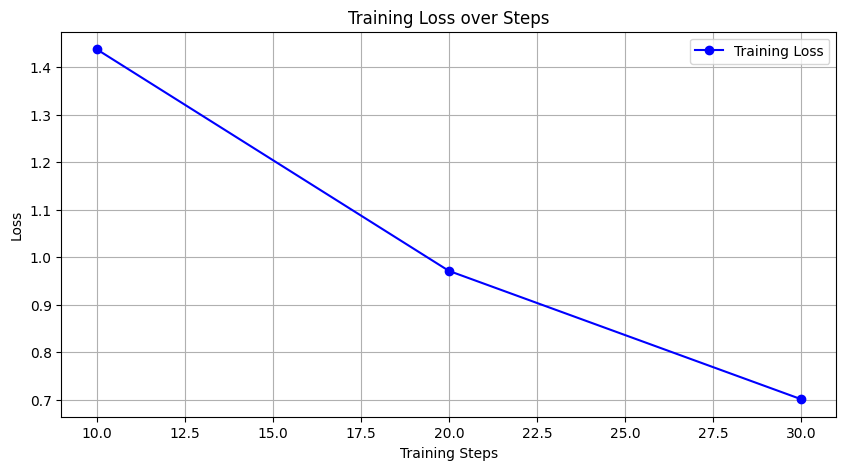

In [215]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract logging history from the Trainer
log_history = trainer.state.log_history

# Filter for training logs that contain loss
loss_logs = [log for log in log_history if 'loss' in log and 'step' in log]

if loss_logs:
    df_logs = pd.DataFrame(loss_logs)

    plt.figure(figsize=(10, 5))
    plt.plot(df_logs['step'], df_logs['loss'], marker='o', linestyle='-', color='b', label='Training Loss')
    plt.title('Training Loss over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No training loss metrics found in log history.")


# Inference with the Fine-Tuned Adapter

In [216]:
def load_finetuned_qwen(model_id=MODEL_ID, adapter_dir=OUTPUT_DIR):
    use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    )

    base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    )
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    processor = AutoProcessor.from_pretrained(adapter_dir)
    return model, processor

def run_finetuned_inference(image_path: str, model, processor):
    image = Image.open(image_path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": USER_PROMPT},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    prompt_len = inputs["input_ids"].shape[1]
    generated_text = processor.tokenizer.decode(
        generated_ids[0][prompt_len:],
        skip_special_tokens=True,
    )

    return generated_text


# Synonyms that the LLM judge collapses to the same GT item; we collapse them
# on the prediction side too so the adapter's line-level output doesn't produce
# two predictions that both match a single GT object (inflating FP, hurting
# precision). Each entry maps canonical_name -> list of forms that collapse
# into it. Canonical forms are chosen to match the style used in the ground
# truth (common short English form), NOT simply the shortest string.
_FT_SYNONYM_MAP = {
    "sofa":             ["sofa", "couch"],
    "television":       ["tv", "television", "flat-screen tv", "flat screen tv"],
    "dining table":     ["dining table"],
    "table":            ["table"],
    "armchair":         ["armchair", "cushioned chair", "accent chair"],
    "shelves":          ["shelves", "shelving unit", "bookshelf", "bookshelves"],
    "curtains":         ["curtains", "drapes", "sheer curtains"],
    "artwork":          ["artwork", "painting", "framed painting", "wall art"],
    "pendant lights":   ["pendant lights", "pendant lamps", "hanging lights"],
    "track lighting":   ["track lighting", "recessed lights", "recessed lighting", "ceiling lights"],
    "wine bottle":      ["wine bottle"],
    "bottle":           ["bottle"],
    "sliding glass door": ["sliding glass door", "glass door", "sliding door"],
    "vase":             ["vase", "glass vase"],
    "tv stand":         ["tv stand", "stand"],
    "cabinet":          ["cabinet", "white cabinet", "storage unit"],
}

# Flatten into form -> canonical lookup
_FT_FORM_TO_CANON = {
    form: canon
    for canon, forms in _FT_SYNONYM_MAP.items()
    for form in forms
}


def _canonical_object_name(name: str) -> str:
    key = name.strip().lower()

    # Try synonym match on the full string first
    if key in _FT_FORM_TO_CANON:
        return _FT_FORM_TO_CANON[key]

    # Strip leading adjective-ish qualifiers that tend to create synonyms
    # ("wooden table" -> "table", "potted orchid" -> "orchid"). Only strip the
    # first word, and only when there are at least two words, to preserve
    # multi-word objects like "coffee table" / "pendant lights".
    QUALIFIERS = {
        "wooden", "metal", "glass", "plastic", "leather", "fabric",
        "large", "small", "tall", "short", "round", "square", "rectangular",
        "white", "black", "gray", "grey", "brown", "beige", "blue", "green",
        "red", "dark", "light", "decorative", "modern", "vintage", "antique",
        "potted", "framed", "cushioned", "sheer",
    }
    parts = key.split()
    if len(parts) >= 2 and parts[0] in QUALIFIERS:
        stripped = " ".join(parts[1:])
        if stripped in _FT_FORM_TO_CANON:
            return _FT_FORM_TO_CANON[stripped]
        return stripped

    return key


def parse_finetuned_output_to_objects(caption: str) -> list:
    """Deterministically turn the adapter's 'object: description' lines into
    a deduped object list. Avoids the LLM extractor pulling extra nouns out of
    descriptions (which was the primary source of false positives)."""
    if not caption:
        return []
    seen = set()
    ordered = []
    for raw_line in caption.splitlines():
        line = raw_line.strip().lstrip("-*0123456789. ").strip()
        if not line or ":" not in line:
            continue
        obj = line.split(":", 1)[0].strip()
        if not obj:
            continue
        canon = _canonical_object_name(obj)
        if canon in seen:
            continue
        seen.add(canon)
        ordered.append(canon)
    return ordered


In [217]:
UPLOADED_IMAGE_PATH = "/content/uploads/test-image.webp"

print(f"Using image: {UPLOADED_IMAGE_PATH}\n")

# Example:
finetuned_model, finetuned_processor = load_finetuned_qwen()
test_output = run_finetuned_inference(UPLOADED_IMAGE_PATH, finetuned_model, finetuned_processor)
print(test_output)

Using image: /content/uploads/test-image.webp



Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

dining table: light wood rectangular table with visible grain pattern
dining chair: wooden chair with curved backrest and beige cushion
potted orchid: white flowers in a small pot on the table
pendant lights: two round white hanging lamps from ceiling
track lighting: linear downlights along the ceiling track
shelving unit: wall-mounted shelves holding figurines and books
sofa: gray upholstered sofa with green throw blanket
coffee table: low round wooden table with tray top
television: flat screen TV on a white stand
curtains: sheer white curtains covering large window
framed picture: green-toned artwork leaning on the floor
wine bottle: green bottle with label on the left side
decorative figurines: small toy-like figures displayed on shelves
storage cabinet: white low cabinet beneath the TV
sliding door: black-framed glass door leading to another room


## Suggested order to run

1. Run your original image-analysis notebook cells if you still want that pipeline.
2. Set `PEXELS_API_KEY` and `OPENAI_API_KEY`.
3. Run dataset generation cells.
4. Check that `train.jsonl` was created.
5. Run the fine-tuning cells.
6. Load the adapter and test inference.

If Colab runs out of memory on 7B, switch `MODEL_ID` to `Qwen/Qwen2.5-VL-3B-Instruct`.


Comparison: Qwen2.5-VL vs Prompt Engineering vs Fine-Tuned

In [218]:
import json
from PIL import Image
from openai import OpenAI

# Ensure image path is set
if not UPLOADED_IMAGE_PATH:
    raise ValueError("Please upload and save an image first.")


def extract_objects_from_caption(caption: str, model="gpt-5.4"):
    """
    Convert a free-text caption/object description into a clean object list.
    Uses the same API key style as your current codebase.
    """
    if not caption or not str(caption).strip():
        return []

    client = OpenAI(api_key=OPENAI_API_KEY)

    system_prompt = """You extract visible household / furniture / room objects from model outputs.

Rules:
1. Return ONLY a JSON list of object names.
2. Keep names short and clean.
3. Include only visible objects mentioned in the text.
4. Do not include room type, scene style, or vague phrases like 'living room' or 'modern apartment'.
5. Merge duplicates where appropriate.
6. If no objects are explicitly mentioned, return [].

Example output:
["sofa", "coffee table", "chairs", "lamp"]
"""

    user_prompt = f"""Text:
{caption}

Return ONLY a JSON list of visible household / furniture / room objects mentioned in the text."""

    try:
        response = client.chat.completions.create(
            model=model,
            max_completion_tokens=200,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )

        output_text = response.choices[0].message.content
        parsed = extract_json_block(output_text)

        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]

        return []

    except Exception as e:
        print(f"Caption extraction failed: {e}")
        return []


def get_raw_qwen_objects(image_path):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "List the visible household objects in this image. Return a comma-separated list."}
        ]}
    ]
    prompt = vision_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = vision_processor(
        text=[prompt],
        images=[image],
        return_tensors="pt"
    ).to(vision_model.device)

    generated_ids = vision_model.generate(**inputs, max_new_tokens=100)
    out_text = vision_processor.batch_decode(
        generated_ids[:, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )[0]

    return [x.strip() for x in out_text.split(",") if x.strip()]


print(f"--- Analyzing image: {UPLOADED_IMAGE_PATH} ---")
print(f"Ground Truth Objects: {len(gt_objects)} found.\n")

# 1. Raw Qwen2.5-VL (Zero-Shot)
print("\n1. Raw Qwen2.5-VL (Zero-Shot):")
raw_qwen_objects = get_raw_qwen_objects(UPLOADED_IMAGE_PATH)
print("Raw Objects Extraction:", raw_qwen_objects)

metrics_raw = evaluate_extraction(raw_qwen_objects, gt_objects)
print("Metrics (Raw Qwen2.5-VL):")
print(json.dumps(metrics_raw, indent=2))


# 2. Prompt-Engineered Qwen2.5-VL
print("\n2. Prompt-Engineered Qwen2.5-VL:")
vision_json, _ = analyze_image_objects(UPLOADED_IMAGE_PATH)
print(json.dumps(vision_json, indent=2, ensure_ascii=False))

predicted_pe = vision_json.get("objects", [])
print("Extracted Objects (Prompt-Engineered):", predicted_pe)

metrics_pe = evaluate_extraction(predicted_pe, gt_objects)
print("Metrics (Prompt-Engineered):")
print(json.dumps(metrics_pe, indent=2))


# 3. Fine-Tuned Qwen2.5-VL (QLoRA)
print("\n3. Fine-Tuned Qwen2.5-VL:")
finetuned_caption = run_finetuned_inference(
    UPLOADED_IMAGE_PATH,
    finetuned_model,
    finetuned_processor
)
print("Fine-Tuned Output:", finetuned_caption)

# The adapter is trained to emit 'object: description' lines, so parse the
# object slot directly and dedupe synonyms. Using the LLM caption extractor
# here would pull extra nouns out of the descriptions (e.g. "blanket" out of
# "gray armchair with a green throw blanket"), inflating FP and hurting F1.
predicted_ft = parse_finetuned_output_to_objects(finetuned_caption)
print("Extracted Objects (Fine-Tuned):", predicted_ft)

metrics_ft = evaluate_extraction(predicted_ft, gt_objects)
print("Metrics (Fine-Tuned Qwen2.5-VL):")
print(json.dumps(metrics_ft, indent=2))


# Final Comparison
comparison_results = {
    "raw_qwen25_vl": metrics_raw,
    "prompt_engineered_qwen25_vl": metrics_pe,
    "fine_tuned_qwen25_vl": metrics_ft
}

print("\n--- Final Comparison ---")
print(json.dumps(comparison_results, indent=2))

--- Analyzing image: /content/uploads/test-image.webp ---
Ground Truth Objects: 21 found.


1. Raw Qwen2.5-VL (Zero-Shot):
Raw Objects Extraction: ['shelves', 'figurines', 'books', 'wine bottle', 'coffee table', 'couch', 'blanket', 'TV stand', 'television', 'pendant lights', 'dining table', 'chairs', 'orchid', 'artwork', 'track lighting', 'sliding glass door', 'curtains', 'floor lamp', 'wall socket.']
Metrics (Raw Qwen2.5-VL):
{
  "precision": 0.84,
  "recall": 0.76,
  "f1_score": 0.8,
  "coverage_percentage": "76.2%",
  "objects_found_ratio": "16/21",
  "true_positives": 16,
  "false_positives": 3,
  "false_negatives": 5,
  "matched_pairs": [
    {
      "predicted": "shelves",
      "ground_truth": "wall shelves"
    },
    {
      "predicted": "figurines",
      "ground_truth": "figurines"
    },
    {
      "predicted": "books",
      "ground_truth": "books"
    },
    {
      "predicted": "wine bottle",
      "ground_truth": "wine bottle"
    },
    {
      "predicted": "coffee ta

## Held-out validation: base vs fine-tuned

Runs raw Qwen2.5-VL and the fine-tuned adapter on the auto-generated
validation split (controlled by `VAL_FRACTION` in the training-config cell),
scores each against the training-label `object:` lines as pseudo ground truth,
and prints mean precision / recall / F1.

Purpose: give every retraining run a comparable number so we can tell whether
changes to the prompt, data, or LoRA config actually help. The pseudo-GT is
the same OpenAI-labeled output the adapter was trained to imitate — so
metrics here answer *"did the adapter fit the target labels?"*, not *"how
well does it generalise to an independent labelling scheme?"*. Treat numbers
as directional, not absolute.

Prereqs: cell 9 (base `vision_model` / `vision_processor` loaded), cells
48 + 49 (fine-tuned adapter loaded into `finetuned_model` /
`finetuned_processor`), and the dataset cell has been re-run so
`dataset_ft["validation"]` exists.

In [219]:
import json as _json
import statistics as _stats


def _parse_gt_lines_to_objects(output_text):
    """Parse 'object: description' training labels into a flat object list."""
    objs = []
    for raw in str(output_text).splitlines():
        line = raw.strip().lstrip("-*0123456789. ").strip()
        if not line or ":" not in line:
            continue
        obj = line.split(":", 1)[0].strip()
        if obj:
            objs.append(obj)
    return objs


def eval_finetune_vs_base_on_val(max_images=None, verbose=True):
    if "validation" not in dataset_ft:
        print("No validation split. Set VAL_FRACTION > 0 (training-config cell) "
              "and re-run the dataset cell.")
        return None

    val_ds = dataset_ft["validation"]
    if max_images is not None:
        val_ds = val_ds.select(range(min(max_images, len(val_ds))))

    rows = []
    for i, ex in enumerate(val_ds):
        gt_objs = _parse_gt_lines_to_objects(ex["output"])

        # 1. Raw
        raw_objs = get_raw_qwen_objects(ex["image"])
        raw_metrics = evaluate_extraction(raw_objs, gt_objs)

        # 2. Prompt-Engineered
        pe_json, _ = analyze_image_objects(ex["image"])
        pe_objs = pe_json.get("objects", []) if pe_json and isinstance(pe_json, dict) else []
        pe_metrics = evaluate_extraction(pe_objs, gt_objs)

        # 3. Fine-Tuned
        ft_caption = run_finetuned_inference(ex["image"], finetuned_model, finetuned_processor)
        ft_objs = parse_finetuned_output_to_objects(ft_caption)
        ft_metrics = evaluate_extraction(ft_objs, gt_objs)

        rows.append({
            "image": ex["image"],
            "n_gt": len(gt_objs),
            "raw_f1": raw_metrics.get("f1_score", 0.0),
            "pe_f1": pe_metrics.get("f1_score", 0.0),
            "ft_f1":  ft_metrics.get("f1_score", 0.0),
            "raw_precision": raw_metrics.get("precision", 0.0),
            "pe_precision": pe_metrics.get("precision", 0.0),
            "ft_precision":  ft_metrics.get("precision", 0.0),
            "raw_recall": raw_metrics.get("recall", 0.0),
            "pe_recall": pe_metrics.get("recall", 0.0),
            "ft_recall":  ft_metrics.get("recall", 0.0),
        })

        if verbose:
            print("[" + str(i + 1) + "/" + str(len(val_ds)) + "] "
                  + "n_gt=" + str(len(gt_objs)).rjust(2) + "  "
                  + "raw_f1=" + format(raw_metrics.get("f1_score", 0), ".2f") + "  "
                  + "pe_f1=" + format(pe_metrics.get("f1_score", 0), ".2f") + "  "
                  + "ft_f1="  + format(ft_metrics.get("f1_score", 0),  ".2f") + "  "
                  + "(" + str(ex["image"]) + ")")

    if not rows:
        return None

    def _mean(k):
        return _stats.fmean(r[k] for r in rows)

    summary = {
        "n_images": len(rows),
        "raw_qwen25_vl": {
            "f1": _mean("raw_f1"),
            "precision": _mean("raw_precision"),
            "recall": _mean("raw_recall"),
        },
        "prompt_engineered_qwen25_vl": {
            "f1": _mean("pe_f1"),
            "precision": _mean("pe_precision"),
            "recall": _mean("pe_recall"),
        },
        "fine_tuned_qwen25_vl": {
            "f1": _mean("ft_f1"),
            "precision": _mean("ft_precision"),
            "recall": _mean("ft_recall"),
        },
        "delta_ft_minus_raw_f1": _mean("ft_f1") - _mean("raw_f1"),
        "delta_ft_minus_pe_f1": _mean("ft_f1") - _mean("pe_f1"),
    }
    print()
    print("--- Held-out validation: base vs prompt-engineered vs fine-tuned (mean across images) ---")
    print(_json.dumps(summary, indent=2))
    return summary, rows


# Run the evaluation. Use max_images=3 for a quick smoke test.
summary, rows = eval_finetune_vs_base_on_val(max_images=None)


[1/16] n_gt=15  raw_f1=0.83  pe_f1=0.62  ft_f1=0.76  (pexels_sg_home_interior_pipeline/images/b1663a97652800d2.jpg)
[2/16] n_gt=11  raw_f1=0.74  pe_f1=0.84  ft_f1=0.91  (pexels_sg_home_interior_pipeline/images/76c774384394729f.jpg)
[3/16] n_gt=15  raw_f1=0.77  pe_f1=0.00  ft_f1=0.79  (pexels_sg_home_interior_pipeline/images/a27c05926560446d.jpg)
[4/16] n_gt=10  raw_f1=0.89  pe_f1=0.82  ft_f1=0.67  (pexels_sg_home_interior_pipeline/images/1619cd00da8b5352.jpg)
[5/16] n_gt=15  raw_f1=0.80  pe_f1=0.64  ft_f1=0.71  (pexels_sg_home_interior_pipeline/images/988269d432f5439b.jpg)
[6/16] n_gt=15  raw_f1=0.67  pe_f1=0.11  ft_f1=0.83  (pexels_sg_home_interior_pipeline/images/0017a41ef2f46eda.jpg)
[7/16] n_gt=15  raw_f1=0.79  pe_f1=0.22  ft_f1=0.77  (pexels_sg_home_interior_pipeline/images/b91fd7805ba30f2e.jpg)
[8/16] n_gt=15  raw_f1=0.76  pe_f1=0.33  ft_f1=0.83  (pexels_sg_home_interior_pipeline/images/4c7dac24b88b24ac.jpg)
[9/16] n_gt=15  raw_f1=0.48  pe_f1=0.00  ft_f1=0.67  (pexels_sg_home_int

### Log Evaluation Metrics to W&B
Run the cell below to log the evaluation results (precision, recall, F1, and a detailed table) to your Weights & Biases project.

In [220]:
import wandb

# Ensure you have run the evaluation first:
# summary, rows = eval_finetune_vs_base_on_val(max_images=None)

if 'summary' in locals() and summary:
    # Initialize a new W&B run for evaluation
    run = wandb.init(
        entity="edward-zj-singapore-university-of-technology-and-design",
        project="Image Analysis (MLOps)",
        name="qwen-vl-finetune-evaluation-10",
        job_type="evaluation",
        reinit=True
    )

    # Log the summary metrics as standard W&B metrics
    wandb.log({
        "val/raw_f1": summary["raw_qwen25_vl"]["f1"],
        "val/raw_precision": summary["raw_qwen25_vl"]["precision"],
        "val/raw_recall": summary["raw_qwen25_vl"]["recall"],
        "val/pe_f1": summary["prompt_engineered_qwen25_vl"]["f1"],
        "val/pe_precision": summary["prompt_engineered_qwen25_vl"]["precision"],
        "val/pe_recall": summary["prompt_engineered_qwen25_vl"]["recall"],
        "val/ft_f1": summary["fine_tuned_qwen25_vl"]["f1"],
        "val/ft_precision": summary["fine_tuned_qwen25_vl"]["precision"],
        "val/ft_recall": summary["fine_tuned_qwen25_vl"]["recall"],
        "val/delta_f1_vs_raw": summary["delta_ft_minus_raw_f1"],
        "val/delta_f1_vs_pe": summary["delta_ft_minus_pe_f1"]
    })

    # Log the detailed row-by-row results as an interactive W&B Table
    table = wandb.Table(columns=[
        "image_path", "num_gt_objects",
        "raw_f1", "pe_f1", "ft_f1",
        "raw_precision", "pe_precision", "ft_precision",
        "raw_recall", "pe_recall", "ft_recall"
    ])

    for row in rows:
        table.add_data(
            row["image"], row["n_gt"],
            row["raw_f1"], row["pe_f1"], row["ft_f1"],
            row["raw_precision"], row["pe_precision"], row["ft_precision"],
            row["raw_recall"], row["pe_recall"], row["ft_recall"]
        )

    wandb.log({"val/evaluation_details": table})

    run.finish()
    print("\n✅ Successfully logged evaluation metrics (Raw, Prompt-Engineered, and Fine-Tuned) and table to W&B! Check your dashboard.")
else:
    print("Please run the eval_finetune_vs_base_on_val() function first to generate 'summary' and 'rows'.")

eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁▄▇██
train/global_step,▁▄▇██
train/grad_norm,▂▁█
train/learning_rate,█▄▁
train/loss,█▄▁
eval/loss,1.26481
eval/runtime,9.6712


val/delta_f1_vs_pe,▁
val/delta_f1_vs_raw,▁
val/ft_f1,▁
val/ft_precision,▁
val/ft_recall,▁
val/pe_f1,▁
val/pe_precision,▁
val/pe_recall,▁
val/raw_f1,▁
val/raw_precision,▁
+1,...



✅ Successfully logged evaluation metrics (Raw, Prompt-Engineered, and Fine-Tuned) and table to W&B! Check your dashboard.


## Project Documentation: Qwen2.5-VL Fine-Tuning with QLoRA

### What Did We Do?
We fine-tuned the `Qwen/Qwen2.5-VL-7B-Instruct` vision-language model to specialize in identifying and describing household objects from interior images. Instead of verbose conversational answers, the model was trained to output clean, strictly formatted `object: description` pairs.

### Dataset
* **Size:** 80 interior images.
* **Source:** Downloaded automatically via the Pexels API using search queries like "Singapore home interior".
* **Labels:** Generated using an OpenAI Vision model to create high-quality, factual ground-truth descriptions.

### What is LoRA?
LoRA (Low-Rank Adaptation) is a parameter-efficient fine-tuning (PEFT) technique. Instead of updating all the weights of the massive pre-trained model, LoRA freezes the original weights and injects small, trainable "rank decomposition matrices" into specific layers (attention and MLP blocks) of the model.

### Why Use LoRA (and QLoRA)?
* **Memory Efficiency:** By combining LoRA with 4-bit quantization (QLoRA), we drastically reduced the memory footprint. This made it possible to train a 7-Billion parameter model on a single, standard Google Colab GPU.
* **Fewer Parameters:** We only train a small fraction of the model's total 8.3 billion parameters.
* **Storage & Portability:** Because we only save the updated LoRA weights (the "adapter"), the final exported model is just tens of megabytes, rather than the 15 GB+ required to duplicate the full model.



In [221]:
import shutil
from google.colab import files

# Zip the adapter directory
zip_filename = "/content/qwen25_vl_7b_objdesc_lora"
shutil.make_archive(zip_filename, 'zip', OUTPUT_DIR)
zip_path = zip_filename + ".zip"

print(f"Zipped model to {zip_path}. Starting download...")
files.download(zip_path)

Zipped model to /content/qwen25_vl_7b_objdesc_lora.zip. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>